In [1]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import optuna
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split, StratifiedKFold
import tensorflow as tf
import numpy as np
from tensorflow.keras import backend as K
import gc
import warnings
from sklearn.inspection import permutation_importance

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fold_1_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/sreenithi/Downloads/data/preprocessed/fold_5_val.csv')

In [3]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [4]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [5]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Feature selection
k_best = 30
selector = SelectKBest(score_func=f_classif, k=k_best)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_val_selected = selector.transform(X_val_scaled)


In [6]:
# Turn data into GRU-compatible format
def create_sequences(X, y, n_steps=7):
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i:i+n_steps])
        ys.append(y[i+n_steps])
    return np.array(Xs).astype('float32'), np.array(ys)

# Make F1 score usable as loss to help with imbalanced metrics
def soft_f1_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    soft_f1 = (2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7)
    return 1 - soft_f1  # minimize

# Hybrid BCE + Soft F1 for better generalization
def hybrid_loss(y_true, y_pred):
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    f1 = soft_f1_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * f1

In [7]:
# Use 10% of training data for faster tuning
X_tune, _, y_tune, _ = train_test_split(X_train_selected, y_train, test_size=0.9, stratify=y_train, random_state=42)

In [8]:
# Compute class weights to handle class imbalance
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}

In [9]:
def objective(trial):
    tf.keras.backend.clear_session()

    # Suggest hyperparameters
    gru_units = trial.suggest_int('gru_units', 64, 256)
    dropout_rate = trial.suggest_float('dropout_rate', 0.3, 0.5)
    n_steps = trial.suggest_int('n_steps', 3, 10)
    batch_size = trial.suggest_int('batch_size', 32, 64)
    threshold = trial.suggest_float("threshold", 0.2, 0.5)

    # Prepare sequences
    X_seq, y_seq = create_sequences(X_tune, y_tune.values, n_steps)

    # GRU model
    model = Sequential([
        GRU(gru_units, activation='relu', input_shape=(n_steps, X_seq.shape[2])),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0005), loss=hybrid_loss)

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(X_seq, y_seq, epochs=3, batch_size=batch_size,
              validation_split=0.2, class_weight=class_weight_dict,
              callbacks=[early_stop], verbose=0)

    preds = model.predict(X_seq).flatten()
    preds_binary = (preds > threshold).astype(int)

    try:
        auc_pr = average_precision_score(y_seq, preds)
    except:
        auc_pr = 0.0

    return auc_pr

# Run Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2025-04-16 14:52:57,333] A new study created in memory with name: no-name-235a9349-db2f-457b-80e9-1672ff3af9d8


17871/17871 ━━━━━━━━━━━━━━━━━━━━ 28s 2ms/step


[I 2025-04-16 14:56:36,378] Trial 0 finished with value: 0.5070102327669903 and parameters: {'gru_units': 122, 'dropout_rate': 0.49744759804329036, 'n_steps': 8, 'batch_size': 52, 'threshold': 0.3213191828172728}. Best is trial 0 with value: 0.5070102327669903.


17871/17871 ━━━━━━━━━━━━━━━━━━━━ 25s 1ms/step


[I 2025-04-16 15:00:30,768] Trial 1 finished with value: 0.5118755939581365 and parameters: {'gru_units': 199, 'dropout_rate': 0.4492510038440011, 'n_steps': 5, 'batch_size': 53, 'threshold': 0.21042539519500053}. Best is trial 1 with value: 0.5118755939581365.


...

17871/17871 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step


[I 2025-04-16 15:33:53,742] Trial 8 finished with value: 0.5113757055929343 and parameters: {'gru_units': 212, 'dropout_rate': 0.4030686015864783, 'n_steps': 4, 'batch_size': 52, 'threshold': 0.22200155345673986}. Best is trial 7 with value: 0.5152416643385344.


17871/17871 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step


[I 2025-04-16 15:39:07,661] Trial 9 finished with value: 0.5187105532584487 and parameters: {'gru_units': 195, 'dropout_rate': 0.3195220414133945, 'n_steps': 7, 'batch_size': 35, 'threshold': 0.24470496821798332}. Best is trial 9 with value: 0.5187105532584487.


Best hyperparameters: {'gru_units': 195, 'dropout_rate': 0.3195220414133945, 'n_steps': 7, 'batch_size': 35, 'threshold': 0.24470496821798332}


In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Best hyperparameters from Optuna tuning with lower batch size to prevent kernel crash
best_params = {
    'gru_units': 195,
    'dropout_rate': 0.3195220414133945,
    'n_steps': 7,
    'batch_size': 32,
    'threshold': 0.24470496821798332
}

# Convert y_train to numpy array for indexing
y_train_np = y_train.values

# Cross-validation setup
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

f1_scores = []
aucpr_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_selected, y_train_np)):
    print(f"\n🟩 Fold {fold + 1}")

    # Split data
    X_train_fold = X_train_selected[train_idx]
    X_val_fold = X_train_selected[val_idx]
    y_train_fold = y_train_np[train_idx]
    y_val_fold = y_train_np[val_idx]

    # Compute class weights
    class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_fold), y=y_train_fold)
    class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}

    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train_fold, y_train_fold, best_params['n_steps'])
    X_val_seq, y_val_seq = create_sequences(X_val_fold, y_val_fold, best_params['n_steps'])

    # Build model
    model = Sequential([
        GRU(best_params['gru_units'], activation='relu', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
        Dropout(best_params['dropout_rate']),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(learning_rate=0.0005), loss=hybrid_loss)

    early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    model.fit(X_train_seq, y_train_seq,
              epochs=5,
              batch_size=best_params['batch_size'],
              class_weight=class_weight_dict,
              callbacks=[early_stop],
              validation_data=(X_val_seq, y_val_seq),
              verbose=1)

    # Evaluate 
    val_probs = model.predict(X_val_seq).flatten()
    val_preds = (val_probs > best_params['threshold']).astype(int)

    f1 = f1_score(y_val_seq, val_preds)
    try:
        auc_pr = average_precision_score(y_val_seq, val_probs)
    except:
        auc_pr = 0.0

    f1_scores.append(f1)
    aucpr_scores.append(auc_pr)

    print(f"Fold {fold + 1} - F1: {f1:.4f}, AUC-PR: {auc_pr:.4f}")
    print(confusion_matrix(y_val_seq, val_preds))
    print(classification_report(y_val_seq, val_preds, digits=4))

# Final evaluations
print("\n✅ Cross-validation complete.")
print(f"Average F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Average AUC-PR Score: {np.mean(aucpr_scores):.4f} ± {np.std(aucpr_scores):.4f}")



🟩 Fold 1
Epoch 1/5
134034/134034 ━━━━━━━━━━━━━━━━━━━━ 953s 7ms/step - loss: 0.0215 - val_loss: 0.2681
Epoch 2/5
134034/134034 ━━━━━━━━━━━━━━━━━━━━ 982s 7ms/step - loss: 0.0203 - val_loss: 0.2679
Epoch 3/5
134034/134034 ━━━━━━━━━━━━━━━━━━━━ 1002s 7ms/step - loss: 0.0209 - val_loss: 0.2678
Epoch 4/5
134034/134034 ━━━━━━━━━━━━━━━━━━━━ 1044s 8ms/step - loss: 0.0275 - val_loss: 0.2761
Epoch 5/5
134034/134034 ━━━━━━━━━━━━━━━━━━━━ 1039s 8ms/step - loss: 0.1628 - val_loss: 0.3102
44678/44678 ━━━━━━━━━━━━━━━━━━━━ 84s 2ms/step
Fold 1 - F1: 0.9946, AUC-PR: 0.9967
[[714797     41]
 [  7692 707153]]
              precision    recall  f1-score   support

           0     0.9894    0.9999    0.9946    714838
           1     0.9999    0.9892    0.9946    714845

    accuracy                         0.9946   1429683
   macro avg     0.9946    0.9946    0.9946   1429683
weighted avg     0.9946    0.9946    0.9946   1429683


🟩 Fold 2
Epoch 1/5
134034/134034 ━━━━━━━━━━━━━━━━━━━━ 2161s 16ms/step - loss:

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd


# 🔁 Create sequences
X_train_seq_full, y_train_seq_full = create_sequences(X_train_selected, y_train.values, best_params['n_steps'])
X_test_seq, y_test_seq = create_sequences(X_val_selected, y_val.values, best_params['n_steps'])

# ⚙️ Define final model
model_final = Sequential([
    GRU(best_params['gru_units'], activation='relu', input_shape=(X_train_seq_full.shape[1], X_train_seq_full.shape[2])),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

model_final.compile(optimizer=Adam(learning_rate=0.0005), loss=hybrid_loss)

# ⚖️ Compute class weights for full training data
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights_array[i] for i in range(len(class_weights_array))}

# 🏋️ Train model on full training data (Folds 1–4)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model_final.fit(X_train_seq_full, y_train_seq_full,
                epochs=5,
                batch_size=best_params['batch_size'],
                class_weight=class_weight_dict,
                callbacks=[early_stop],
                validation_split=0.1,
                verbose=1)

# 🟩 Evaluate on Fold 5 (Holdout Test Set)
print("\n🟩 Evaluating on Fold 5 (Holdout Test Set)")

# 🔮 Predict
test_probs = model_final.predict(X_test_seq).flatten()
test_preds = (test_probs > best_params['threshold']).astype(int)

# 📊 Evaluate
try:
    auc_pr_test = average_precision_score(y_test_seq, test_probs)
except:
    auc_pr_test = 0.0

f1_test = f1_score(y_test_seq, test_preds)

print(f"\n✅ Evaluation on Fold 5 (Holdout Test Set)")
print(f"F1: {f1_test:.4f}")
print(f"AUC-PR: {auc_pr_test:.4f}")
print(confusion_matrix(y_test_seq, test_preds))
print(classification_report(y_test_seq, test_preds, digits=4))


Epoch 1/5
160840/160840 ━━━━━━━━━━━━━━━━━━━━ 1376s 9ms/step - loss: 0.0238 - val_loss: 1.1752e-04
Epoch 2/5
160840/160840 ━━━━━━━━━━━━━━━━━━━━ 1406s 9ms/step - loss: 0.0227 - val_loss: 5.1310e-04
Epoch 3/5
160840/160840 ━━━━━━━━━━━━━━━━━━━━ 1348s 8ms/step - loss: 0.0236 - val_loss: 0.0017

🟩 Evaluating on Fold 5 (Holdout Test Set)
5645/5645 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step

✅ Evaluation on Fold 5 (Holdout Test Set)
F1: 0.0000
AUC-PR: 0.0110
[[178697      7]
 [  1920      0]]
              precision    recall  f1-score   support

           0     0.9894    1.0000    0.9946    178704
           1     0.0000    0.0000    0.0000      1920

    accuracy                         0.9893    180624
   macro avg     0.4947    0.5000    0.4973    180624
weighted avg     0.9789    0.9893    0.9841    180624




🔎 Evaluation on Validation Set
Classification Report:
              precision    recall  f1-score   support

           0     0.9894    1.0000    0.9946    714837
           1     1.0000    0.9892    0.9946    714845

    accuracy                         0.9946   1429682
   macro avg     0.9947    0.9946    0.9946   1429682
weighted avg     0.9947    0.9946    0.9946   1429682


Confusion Matrix:
[[714814     23]
 [  7686 707159]]

Precision: 1.0000
Recall:    0.9892
F1 Score:  0.9946
AUC-PR (Average Precision): 0.9968
ROC AUC:                   0.9948


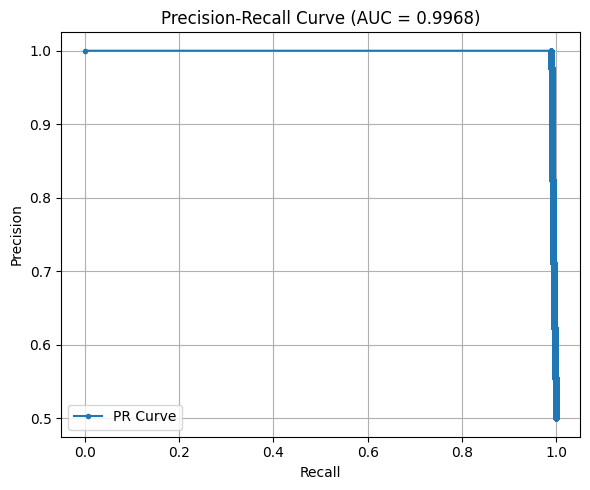

{'precision': 0.9999674765477629,
 'recall': 0.9892480188012786,
 'f1_score': 0.9945788652395489,
 'confusion_matrix': [[714814, 23], [7686, 707159]],
 'auc_pr': 0.9967563683389306,
 'roc_auc': 0.9947822073760448}

In [13]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    if y_proba is not None:
        # AUC-PR
        pr_auc = average_precision_score(y_true, y_proba)
        roc_auc = roc_auc_score(y_true, y_proba)

        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")
        print(f"ROC AUC:                   {roc_auc:.4f}")

        metrics['auc_pr'] = pr_auc
        metrics['roc_auc'] = roc_auc

        # PR Curve
        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

# Evaluate model 
print("\n🔎 Evaluation on Validation Set")
evaluate_model(y_val_seq, val_preds, y_proba=val_probs)
